<a href="https://colab.research.google.com/github/Ebrardemir/amazon-sentiment-analysis/blob/main/Veri_Okuma.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Amazon Dataset Reviews 2023 Verilerinden Duygu Analizi
Bu projede, Amazon Reviews 2023  Dateseti içerisinden aldığımız Electronic kategorisinin verileri için duygu analizi yapıyoruz.

In [1]:
import gzip
import json
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
input_path = '/content/drive/MyDrive/Veri_madenciliği/Dataset/Electronics.jsonl.gz'

# Satır ve Sütun Analizi
Aşağıdaki hücrede kullandığımız Electronics.json.gz dosyasında kaç satır ,kaç sütun ve hangi sütunların bulunduğunun analizini yapıyoruz.

In [ ]:

row_count = 0
columns = []

print("Dosya taranıyor, bu işlem birkaç dakika sürebilir...")
with gzip.open(input_path, 'rt', encoding='utf-8') as f:
    for line in f:
        if row_count == 0:
            # Sütun isimlerini alalım
            columns = list(json.loads(line).keys())
        row_count += 1

        #Kodun düzenli çalışıp çalışmadığını görmek için her 1.000.000 da ekrana yazdırıyoruz.
        if row_count % 1000000 == 0:
            print(f"{row_count // 1000000} milyon satır sayıldı...")

print("\n--- ANALİZ SONUCU ---")
print(f"Toplam Satır Sayısı: {row_count:,}")
print(f"Toplam Sütun Sayısı: {len(columns)}")
print(f"Sütun İsimleri: {columns}")


Dosya taranıyor, bu işlem birkaç dakika sürebilir...
1 milyon satır sayıldı...
2 milyon satır sayıldı...
3 milyon satır sayıldı...
4 milyon satır sayıldı...
5 milyon satır sayıldı...
6 milyon satır sayıldı...
7 milyon satır sayıldı...
8 milyon satır sayıldı...
9 milyon satır sayıldı...
10 milyon satır sayıldı...
11 milyon satır sayıldı...
12 milyon satır sayıldı...
13 milyon satır sayıldı...
14 milyon satır sayıldı...
15 milyon satır sayıldı...
16 milyon satır sayıldı...
17 milyon satır sayıldı...
18 milyon satır sayıldı...
19 milyon satır sayıldı...
20 milyon satır sayıldı...
21 milyon satır sayıldı...
22 milyon satır sayıldı...
23 milyon satır sayıldı...
24 milyon satır sayıldı...
25 milyon satır sayıldı...
26 milyon satır sayıldı...
27 milyon satır sayıldı...
28 milyon satır sayıldı...
29 milyon satır sayıldı...
30 milyon satır sayıldı...
31 milyon satır sayıldı...
32 milyon satır sayıldı...
33 milyon satır sayıldı...
34 milyon satır sayıldı...
35 milyon satır sayıldı...
36 milyon s

Verinin içeriğini görmek için ilk 5 satırı ekrana bastırdık.

In [3]:
import pandas as pd


preview_data = []
with gzip.open(input_path, 'rt', encoding='utf-8') as f:
    for i, line in enumerate(f):
        preview_data.append(json.loads(line))
        if i == 4:
            break

# Pandas ile tablo olarak göster
df_preview = pd.DataFrame(preview_data)
pd.set_option('display.max_columns', None)
print(df_preview)

   rating                                        title  \
0     3.0            Smells like gasoline! Going back!   
1     1.0      Didn’t work at all lenses loose/broken.   
2     5.0                                   Excellent!   
3     5.0                       Great laptop backpack!   
4     5.0  Best Headphones in the Fifties price range!   

                                                text  \
0  First & most offensive: they reek of gasoline ...   
1  These didn’t work. Idk if they were damaged in...   
2  I love these. They even come with a carry case...   
3  I was searching for a sturdy backpack for scho...   
4  I've bought these headphones three times becau...   

                                              images        asin parent_asin  \
0  [{'small_image_url': 'https://m.media-amazon.c...  B083NRGZMM  B083NRGZMM   
1                                                 []  B07N69T6TM  B07N69T6TM   
2                                                 []  B01G8JO5F2  B01G8JO5

# Rating Yorum Grafiği
Bu bölümde, elimizdeki ham veri setindeki ürün yorumlarının yıldız (rating) dağılımını görselleştiriyoruz. Bu grafik, kullanıcıların ürünlere verdiği puanların genel eğilimini ve hangi yıldız puanlarının daha yoğun olduğunu anlamamızı sağlayacaktır. Özellikle 1, 2, 3, 4 ve 5 yıldızlı yorumların sayısal dağılımını bar grafik üzerinde görebilirsiniz.

Satırlar taranıyor, rating dağılım grafiği hazırlanıyor...
10 milyon satır işlendi...
20 milyon satır işlendi...
30 milyon satır işlendi...
40 milyon satır işlendi...


/tmp/ipykernel_11355/3230293850.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ratings, y=counts, palette='viridis', edgecolor='black')


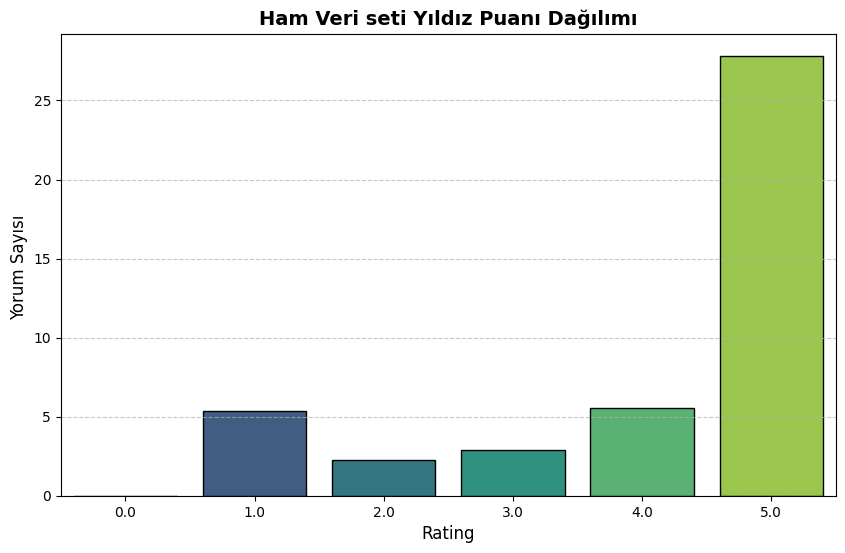


--- ANALİZ SONUÇLARI ---
0.0 Yıldız: 2 yorum
1.0 Yıldız: 5,358,800 yorum
2.0 Yıldız: 2,257,604 yorum
3.0 Yıldız: 2,883,065 yorum
4.0 Yıldız: 5,557,725 yorum
5.0 Yıldız: 27,829,748 yorum


In [13]:
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import os

rating_counts = Counter()
print("Satırlar taranıyor, rating dağılım grafiği hazırlanıyor...")

with gzip.open(input_path, 'rt', encoding='utf-8') as f:
    for i, line in enumerate(f):
        data = json.loads(line)
        r = data.get('rating')
        if r is not None:
            rating_counts[r] += 1

        if i % 10000000 == 0 and i > 0:
            print(f"{i // 1000000} milyon satır işlendi...")


ratings = sorted(rating_counts.keys())
counts = [rating_counts[r] for r in ratings]

plt.figure(figsize=(10, 6))
sns.barplot(x=ratings, y=counts, palette='viridis', edgecolor='black')


plt.title('Ham Veri seti Yıldız Puanı Dağılımı', fontsize=14, fontweight='bold')
plt.xlabel('Rating', fontsize=12)
plt.ylabel('Yorum Sayısı ', fontsize=12)


plt.gca().get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x/1e6), ',')))

plt.grid(axis='y', linestyle='--', alpha=0.7)


plot_output_dir = '/content/drive/MyDrive/Veri_madenciliği/Grafik/'


if not os.path.exists(plot_output_dir):
    os.makedirs(plot_output_dir)

plt.savefig(os.path.join(plot_output_dir, 'rating_dagilimi_analizi.png'), dpi=300)
plt.show()

print("\n--- ANALİZ SONUÇLARI ---")
for r, count in sorted(rating_counts.items()):
    print(f"{r} Yıldız: {count:,} yorum")

# Çalışma Verisi Oluşturma

Bu bölümde, orijinal büyük veri setinden duygu analizi modellememiz için daha yönetilebilir bir alt küme oluşturuyoruz. Her bir derecelendirme (1, 2, 4 ve 5 yıldız) kategorisinden eşit sayıda (her birinden 200.000 adet) örnek seçerek toplamda 800.000 satırlık dengeli bir çalışma veri seti oluşturuyoruz. Bu işlem, hem veri dağılımını korumamızı sağlar hem de analizlerimizi daha hızlı ve verimli bir şekilde yapabilmemize olanak tanır. Oluşturulan veri seti CSV formatında kaydediliyor.

In [12]:
import pandas as pd
import gzip
import json
import random
import os


output_path = '/content/drive/MyDrive/Veri_madenciliği/Dataset/electronics_calisma_verisi_800k.csv'


limit_per_rating = 200000
data_list = {1.0: [], 2.0: [], 4.0: [], 5.0: []}

print("Satır taranıyor. Her gruptan 200.000 örnek  toplanıyor.")

with gzip.open(input_path, 'rt', encoding='utf-8') as f:
    for i, line in enumerate(f):
        # Doğru bir örneklem olması için  her 5 satırdan 1 ini alıyoruz.
        if i % 5 != 0:
            continue

        item = json.loads(line)
        r = item.get('rating')

        #  1, 2, 4 ve 5 yıldızlar
        if r in data_list and len(data_list[r]) < limit_per_rating:
            data_list[r].append({
                'rating': int(r), # Tam sayı olarak saklayalım
                'title': item.get('title', ''),
                'text': item.get('text', ''),
                'verified_purchase': item.get('verified_purchase'),
                'timestamp': item.get('timestamp'),
                'helpful_vote': item.get('helpful_vote', 0)
            })

        # Tüm kontenjanlar dolduğunda dur
        if all(len(v) >= limit_per_rating for v in data_list.values()):
            break

# Verileri birleştir ve KARIŞTIR (Shuffle) - Bu çok önemli!
all_data = []
for r_list in data_list.values():
    all_data.extend(r_list)

print("Sıralı dizim olmaması için shuffle kullanılıyor.")
random.shuffle(all_data)


directory = os.path.dirname(output_path)
if not os.path.exists(directory):
    os.makedirs(directory)

# CSV olarak kaydet
df_final = pd.DataFrame(all_data)
df_final.to_csv(output_path, index=False)

print(f"\n{len(df_final)} satırlık örnek uzay oluşturuldu.")


Satır taranıyor. Her gruptan 200.000 örnek  toplanıyor.
Sıralı dizim olmaması için shuffle kullanılıyor.

800000 satırlık örnek uzay oluşturuldu.
